In [8]:
import torch

import xarray as xr
import numpy as np
import pandas as pd

from constants import *
from neural_net import get_net

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [9]:
torch.manual_seed(10)

# Settings

In [10]:
device = torch.device("cuda:1")
dtype = torch.bfloat16

In [31]:
batch_size = 32

# Number of ensemble members
n_ensemble = 4

# Integration steps for flow model
n_int = 10

# Load data

In [32]:
ds_test = xr.open_zarr("../data/sqg_test.zarr")["q"].compute()

# Flow matching generation

In [33]:
delta_t = 1 / n_int

def sample_with_flow(flow_model, n_samples, H, W):
    device = next(flow_model.parameters()).device
    dtype = next(flow_model.parameters()).dtype

    # initial state, sampled like gaussian noise
    dynamics = torch.randn(n_samples, 1, H, W, device=device, dtype=dtype)
    for t in np.linspace(0, 1, n_int+1)[:-1]:
        # time vector 
        pseudo_time = torch.full((n_samples, 1), t, device=device, dtype=dtype)
        # velocity learnt by model at current dynamics and time  
        velocity = flow_model(dynamics, pseudo_time)
        # euler integration of continuous flow 
        # xt+dt = xt + dt f(xt, t) 
        dynamics = dynamics + delta_t * velocity
    return dynamics

In [34]:
ckpt = torch.load("../data/best_flowmodel_test.ckpt", map_location="cpu")
cfg = ckpt["config"]
cfg["n_heads"] = 4

flow_model = get_net(
    n_input=cfg["n_input"],
    n_output=cfg["n_output"],
    n_blocks=cfg["n_blocks"],
    n_heads =cfg["n_heads"],
    n_features=cfg["n_features"],
    n_embedding=cfg["n_embedding"],
    wave_length=cfg["wave_length"],
    device=device,
    dtype=dtype,
)

# Load weights
flow_model.load_state_dict(ckpt["model_state_dict"])

# Switch to eval + move to device
flow_model = flow_model.eval().to(device=device, dtype=dtype)

# Optional: compile for speed
flow_model = torch.compile(flow_model, mode="reduce-overhead")

In [35]:
flow_mse_ens = []
flow_mse_mean = []
flow_spread = []

n_times_total = ds_test.sizes["time"]
pbar = tqdm(np.arange(0, n_times_total, batch_size))

for start_idx in pbar:
    # Ground-truth batch (only for statistics, not initialization)
    truth = ds_test[start_idx:start_idx + batch_size]
    # loop processes test dataset in chunks of batch_size time steps 
    n_batch = truth.sizes["time"]
    C, H, W = truth.shape[1:]

    # ============================================================
    # Sample ensemble from invariant distribution
    # ============================================================
    with torch.no_grad():
        samples = sample_with_flow(
            flow_model,
            n_samples=n_ensemble * n_batch,
            H=H,
            W=W,
        ) 
    # call the function in time loop, at each iteration we denoise 
    samples = samples * float(in_std) + float(in_mean)  # denormalize
    samples = samples.reshape(n_ensemble, n_batch, C, H, W).cpu().float().numpy()

    # ============================================================
    # Ensemble MSE against independent truth snapshots
    # ============================================================
    truth_expanded = truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0)

    error = samples - truth_expanded
    mse_ens = (error**2).mean(["ensemble", "longitude", "latitude"])
    flow_mse_ens.append(mse_ens)

    # ============================================================
    # Ensemble-mean MSE
    # ============================================================
    error_mean = samples.mean(axis=0) - truth
    mse_mean = (error_mean**2).mean(["longitude", "latitude"])
    flow_mse_mean.append(mse_mean)

    # ============================================================
    # Spread (ensemble variance)
    # ============================================================
    variance = samples.var(axis=0, ddof=1)
    variance = truth.copy(data=variance)
    spread = variance.mean(["longitude", "latitude"])
    flow_spread.append(spread)

# Concatenate over time
flow_mse_ens = xr.concat(flow_mse_ens, dim="time")
flow_mse_mean = xr.concat(flow_mse_mean, dim="time")
flow_spread = xr.concat(flow_spread, dim="time")

  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Confirm: check velocity magnitude at different pseudo-times
flow_model.eval()
with torch.no_grad():
    x = torch.randn(8, 1, H, W, device=device, dtype=dtype)
    for t_val in [0.0, 0.25, 0.5, 0.75, 1.0]:
        pt = torch.full((8, 1), t_val, device=device, dtype=dtype)
        v  = flow_model(x, pt)
        print(f"  t={t_val:.2f}  v_std={v.std():.4f}  v_mean={v.mean():.4f}")

  t=0.00  v_std=0.8867  v_mean=0.0031
  t=0.25  v_std=1.0156  v_mean=-0.0330
  t=0.50  v_std=1.2422  v_mean=-0.0889
  t=0.75  v_std=1.1875  v_mean=-0.0933
  t=1.00  v_std=0.5312  v_mean=-0.0938


In [37]:
import matplotlib.gridspec as gridspec
from scipy import stats

## Helper functions 

In [38]:
# physical parameters
f   = 1.5e-4
L   = 1100 * 1e3
Ro  = 0.011607
N   = 30 * f
U   = Ro * f * L

def plot_q(q, ax=None, title='', cbar=False):
    # Plot a 2D vorticity field. q should be shape (H, W).
    if ax is None:
        fig, ax = plt.subplots()
    q = np.asarray(q).squeeze()          # ensure 2-D
    assert q.ndim == 2, f"Expected 2D array, got shape {q.shape}"
    qmax = np.abs(q).max()
    pc = ax.pcolormesh(
        np.linspace(0, 2*np.pi, q.shape[1] + 1),   # (W+1,) cell edges
        np.linspace(0, 2*np.pi, q.shape[0] + 1),   # (H+1,) cell edges
        q, cmap='seismic', vmin=-qmax, vmax=qmax,
        shading='flat'
    )
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return pc

def calc_ispec(M, _var_dens, averaging=True, truncate=True, nfactor=1):
    """Isotropic spectrum from 2-D rfft2 power spectrum (M x M//2+1)."""
    var_dens = np.copy(_var_dens)
    var_dens[...,  0] /= 2
    var_dens[..., -1] /= 2

    ll = np.fft.fftfreq(M) * M
    kk = np.arange(0, M // 2 + 1)
    k2d, l2d = np.meshgrid(kk, ll)
    wv = np.sqrt(k2d**2 + l2d**2)

    kmax = np.minimum(np.abs(ll).max(), np.abs(kk).max()) if truncate \
           else np.sqrt(np.abs(ll).max()**2 + np.abs(kk).max()**2)
    dkr  = np.sqrt(2) * nfactor
    kr   = np.arange(0, kmax, dkr)
    phr  = np.zeros(kr.size)

    for i in range(kr.size):
        if i == kr.size - 1:
            mask = (wv >= kr[i]) & (wv <= kr[i] + dkr)
        else:
            mask = (wv >= kr[i]) & (wv < kr[i+1])
        phr[i] = (var_dens[mask].mean() * (kr[i] + dkr/2) * np.pi / 1
                  if averaging else var_dens[mask].sum() / dkr)
        phr[i] *= 2
    return kr + dkr/2, phr


def q_to_spec(q_2d, L=L, U=U):
    """
    q_2d : np.ndarray, shape (H, W) — single snapshot of PV.
    Returns (kr [m^-1], enstrophy_spectrum).
    """
    q_2d = np.asarray(q_2d).squeeze()
    assert q_2d.ndim == 2
    M = q_2d.shape[-1]
    vovo     = np.fft.rfft2(q_2d)
    ener_spec = np.abs(vovo)**2 / M**2          # (M, M//2+1)
    kr, enst  = calc_ispec(M, ener_spec)
    enst = enst * U**2 / L
    kr   = kr   / L
    return kr, enst


def mean_spectrum(q_array, L=L, U=U):
    """
    Average spectrum over a collection of snapshots.
    q_array: (N, H, W) or (N, 1, H, W)
    """
    q_array = np.asarray(q_array).squeeze()
    if q_array.ndim == 2:
        q_array = q_array[None]
    spectra = []
    for q in q_array:
        kr, s = q_to_spec(q, L=L, U=U)
        spectra.append(s)
    return kr, np.stack(spectra)

def savefig(name, dpi=150):
    plt.savefig(f"{name}.png", dpi=dpi, bbox_inches="tight")
    plt.show()

## Flow Matching — Generative Model Evaluation for SQG PV
=======================================================
The model samples from the INVARIANT DISTRIBUTION (unconditional generation),
so there is no forecast aspect. Evaluation has two parts:

Part A — Scalar diagnostics (from precomputed flow_mse_ens / _mean / spread)
  A1. MSE over the test set (ens-member MSE and ens-mean MSE)
  A2. Spread vs skill (ensemble calibration)
  A3. CRPS decomposition

Part B — Field & spectral analysis (requires a fresh sample batch)
  B1. Visual inspection — generated fields vs truth
  B2. Spectral fidelity — enstrophy spectra
  B3. Marginal statistics — PDF, Q-Q, pixelwise moments

Assumed shapes going in
-----------------------
ds_test           : xr.DataArray  (T, 1, H, W)   T=72, H=W=512
flow_mse_ens      : xr.DataArray  (T, 1)   MSE averaged over ensemble+space
flow_mse_mean     : xr.DataArray  (T, 1)   MSE of ens-mean vs truth, over space
flow_spread       : xr.DataArray  (T, 1)   ensemble variance averaged over space

In [39]:
def savefig(name, dpi=150):
    #plt.savefig(f"{name}.png", dpi=dpi, bbox_inches="tight")
    plt.show()
    # print(f"  → saved {name}.png")

In [ ]:
# Debugging: Check truth statistics
print("=== Truth Statistics ===")
truth_all = np.asarray(ds_test).squeeze(axis=1)  # (T, H, W)
print(f"Truth shape: {truth_all.shape}")
print(f"Truth mean: {truth_all.mean():.6f}")
print(f"Truth std: {truth_all.std():.6f}")
print(f"Truth min: {truth_all.min():.6f}, max: {truth_all.max():.6f}")

# Normalized truth (as model sees it)
norm_truth = (truth_all - float(in_mean)) / float(in_std)
print(f"Normalized truth mean: {norm_truth.mean():.6f}")
print(f"Normalized truth std: {norm_truth.std():.6f}")

=== Shape audit ===
  ds_test       : ('time', 'var_name', 'longitude', 'latitude')  (72, 1, 512, 512)
  flow_mse_ens  : ('time', 'var_name')  (72, 1)
  flow_mse_mean : ('time', 'var_name')  (72, 1)
  flow_spread   : ('time', 'var_name')  (72, 1)

  T=72  H=512  W=512

[A1] MSE time series


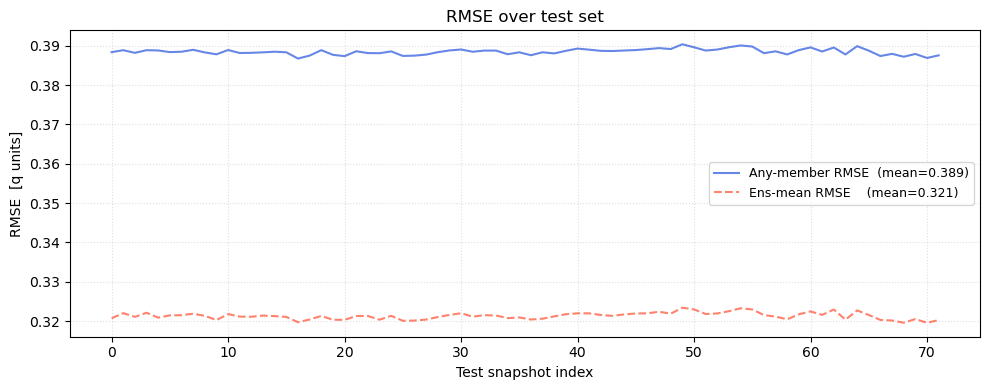

[A2] Spread-skill


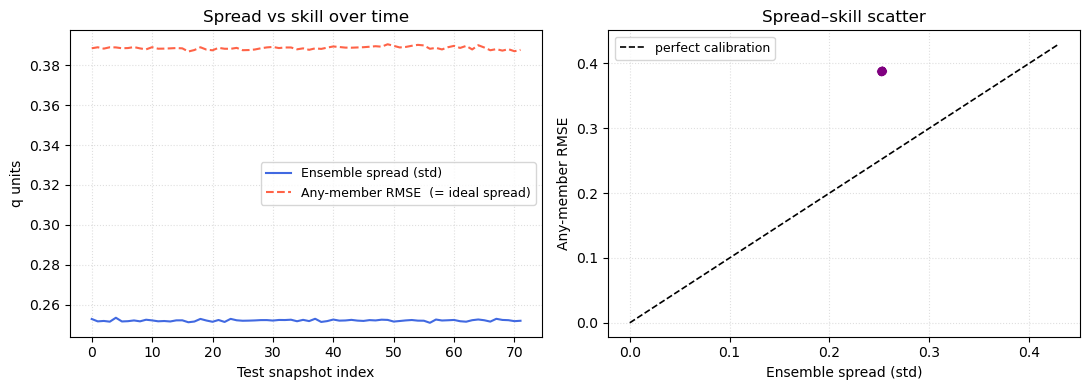

  Mean spread/RMSE = 0.649   (1.0 = perfect, <1 = overconfident)
[A3] Ens-mean skill gain
  Mean(rmse_mean / rmse_ens) = 0.827  (expect ~0.500 for 4 independent members)


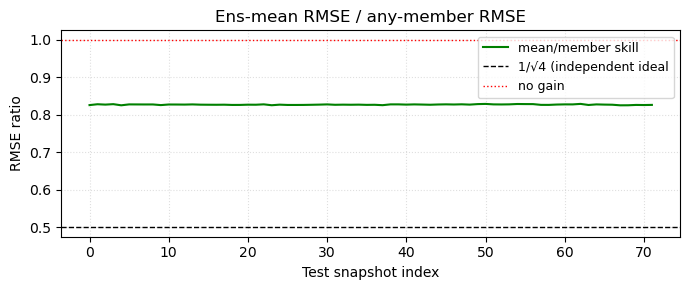


[B] Generating 8 samples for field & spectral analysis ...
  gen_viz shape   : torch.Size([8, 1, 512, 512])
  truth_viz shape : (8, 512, 512)
  gen_viz   mean=-0.001  std=0.252
  truth_viz mean=0.000  std=0.296
[B1] Visual inspection


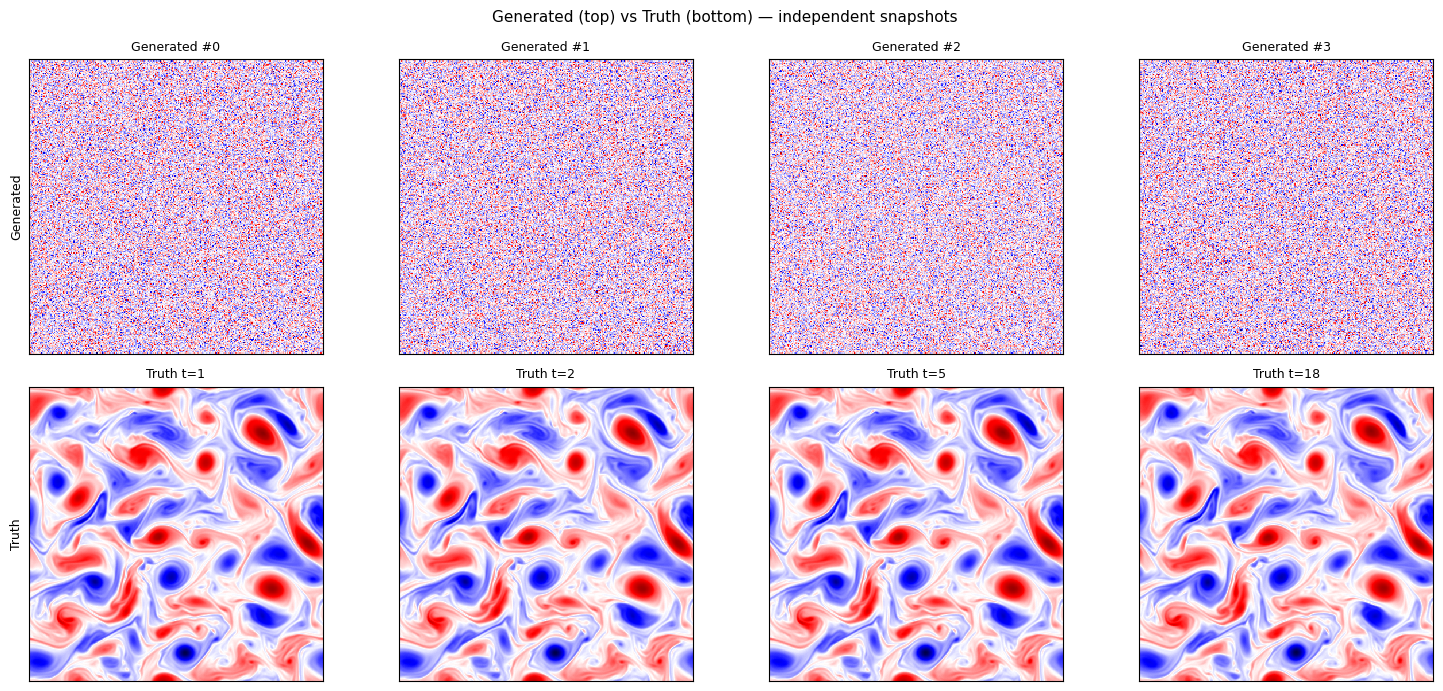

[B2] Spectral analysis


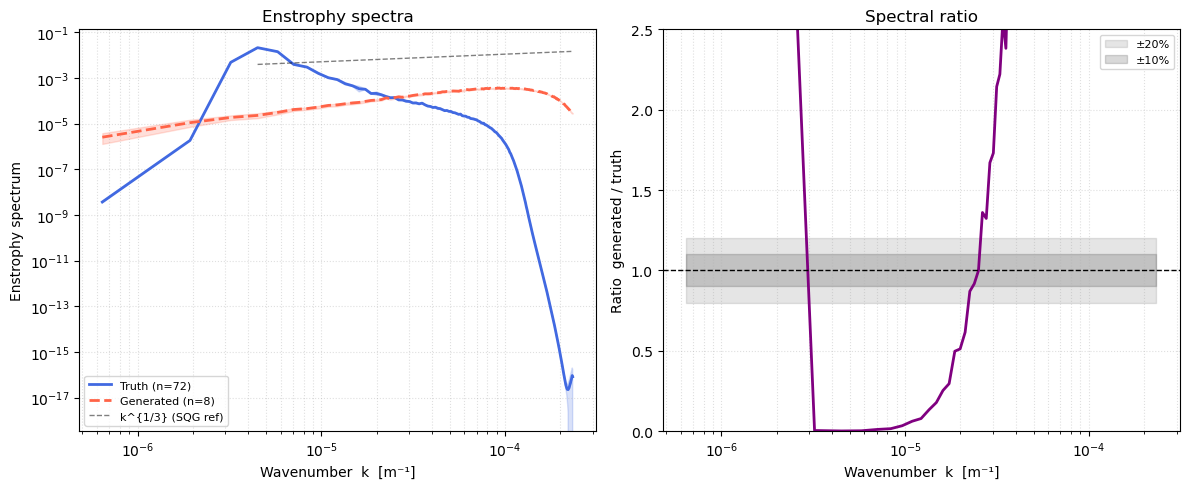

  Spectral accuracy within ±10%: 1.1%
  Spectral accuracy within ±20%: 1.6%
[B3] Marginal statistics


TypeError: cannot unpack non-iterable ellipsis object

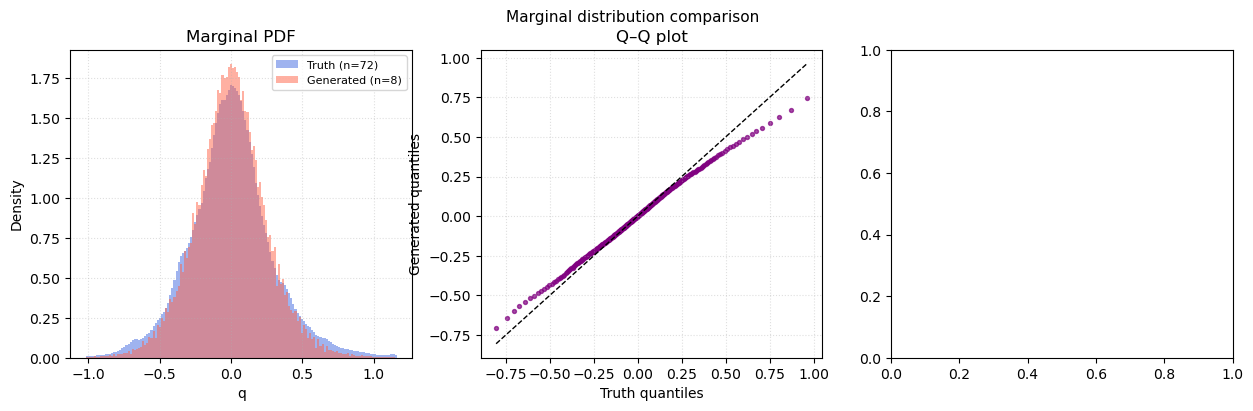

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 0.  SHAPE AUDIT — run this first to verify everything
# ════════════════════════════════════════════════════════════════════════════
print("=== Shape audit ===")
print(f"  ds_test       : {ds_test.dims}  {ds_test.shape}")
print(f"  flow_mse_ens  : {flow_mse_ens.dims}  {flow_mse_ens.shape}")
print(f"  flow_mse_mean : {flow_mse_mean.dims}  {flow_mse_mean.shape}")
print(f"  flow_spread   : {flow_spread.dims}  {flow_spread.shape}")

# Scalar time series — squeeze out the channel dim (size 1)
mse_ens  = np.asarray(flow_mse_ens).squeeze()    # (T,)
mse_mean = np.asarray(flow_mse_mean).squeeze()   # (T,)
spread   = np.asarray(flow_spread).squeeze()      # (T,) — this is VARIANCE

T = mse_ens.shape[0]
T_true, _, H, W = ds_test.shape
print(f"\n  T={T}  H={H}  W={W}")
assert T == T_true, f"T mismatch: mse has {T} points but ds_test has {T_true}"

# ════════════════════════════════════════════════════════════════════════════
# PART A — SCALAR DIAGNOSTICS (no new samples needed)
# ════════════════════════════════════════════════════════════════════════════

# ── A1. MSE time series ─────────────────────────────────────────────────────
print("\n[A1] MSE time series")
rmse_ens  = np.sqrt(mse_ens)    # RMSE per time step (any member vs its truth)
rmse_mean = np.sqrt(mse_mean)   # RMSE of ens-mean vs truth

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rmse_ens,  lw=1.5, color="royalblue", alpha=0.8,
        label=f"Any-member RMSE  (mean={rmse_ens.mean():.3f})")
ax.plot(rmse_mean, lw=1.5, color="tomato",    alpha=0.8, ls="--",
        label=f"Ens-mean RMSE    (mean={rmse_mean.mean():.3f})")
ax.set_xlabel("Test snapshot index")
ax.set_ylabel("RMSE  [q units]")
ax.set_title("RMSE over test set")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig("A1_rmse_timeseries")

# ── A2. Spread–skill (calibration) ─────────────────────────────────────────
print("[A2] Spread-skill")
# spread is ensemble VARIANCE → take sqrt for std, compare to member RMSE
#   perfect calibration: spread_std ≈ rmse_ens
spread_std = np.sqrt(spread)    # (T,)  ensemble std (spatial average)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(spread_std, lw=1.5, color="royalblue", label="Ensemble spread (std)")
ax.plot(rmse_ens,   lw=1.5, color="tomato", ls="--",
        label="Any-member RMSE  (= ideal spread)")
ax.set_xlabel("Test snapshot index")
ax.set_ylabel("q units")
ax.set_title("Spread vs skill over time")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)

ax = axes[1]
ax.scatter(spread_std, rmse_ens, s=18, alpha=0.6, color="purple")
lim = max(spread_std.max(), rmse_ens.max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", lw=1.2, label="perfect calibration")
ax.set_xlabel("Ensemble spread (std)")
ax.set_ylabel("Any-member RMSE")
ax.set_title("Spread–skill scatter")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig("A2_spread_skill")

ratio = (spread_std / (rmse_ens + 1e-12)).mean()
print(f"  Mean spread/RMSE = {ratio:.3f}   (1.0 = perfect, <1 = overconfident)")


# ── A3. Ensemble-mean skill gain ─────────────────────────────────────────────
# Ens-mean RMSE should be < any-member RMSE by factor ~1/sqrt(N_ens)
# (this only holds if members are independent, which they should be here)
print("[A3] Ens-mean skill gain")
ratio_mm = rmse_mean / (rmse_ens + 1e-12)
print(f"  Mean(rmse_mean / rmse_ens) = {ratio_mm.mean():.3f}  "
      f"(expect ~{1/np.sqrt(n_ensemble):.3f} for {n_ensemble} independent members)")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ratio_mm, color="green", lw=1.5, label = "mean/member skill")
ax.axhline(1/np.sqrt(n_ensemble), color="k", ls="--", lw=1,
           label=f"1/√{n_ensemble} (independent ideal")
ax.axhline(1.0, color="red", ls=":", lw=1, label="no gain")
ax.set_xlabel("Test snapshot index")
ax.set_ylabel("RMSE ratio")
ax.set_title("Ens-mean RMSE / any-member RMSE")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig("A3_ensmean_skill_gain")



# ════════════════════════════════════════════════════════════════════════════
# PART B — FIELD & SPECTRAL ANALYSIS
# Generate a fresh batch of N_VIZ samples once (no truth needed for B1/B2/B3)
# and pick N_VIZ random truth snapshots for comparison
# ════════════════════════════════════════════════════════════════════════════

import torch
N_VIZ = 8   # number of fields to show / use for spectra

print(f"\n[B] Generating {N_VIZ} samples for field & spectral analysis ...")
with torch.no_grad():
    raw_gen = sample_with_flow(flow_model, n_samples=N_VIZ, H=H, W=W)
    print(f"  Raw generated shape: {raw_gen.shape}")
    print(f"  Raw generated mean: {raw_gen.mean():.6f}, std: {raw_gen.std():.6f}")
    print(f"  Expected normalized mean: 0, std: 1")
    gen_viz = raw_gen * float(in_std) + float(in_mean)
    
    # pick N_VIZ random truth snapshots
    rng = np.random.default_rng(0)
    idx_viz = rng.choice(T_true, size=N_VIZ, replace=False)
    idx_viz.sort()
    truth_viz = np.asarray(ds_test[idx_viz]).squeeze(axis=1)   # (N_VIZ, H, W)
    
    print(f"  gen_viz shape   : {gen_viz.shape}")
    print(f"  truth_viz shape : {truth_viz.shape}")

    # Right after generating gen_viz:
    print(f"  gen_viz   mean={gen_viz.mean():.3f}  std={gen_viz.std():.3f}")
    print(f"  truth_viz mean={truth_viz.mean():.3f}  std={truth_viz.std():.3f}")

    # Debugging: Plot raw generated fields
    fig, axes = plt.subplots(1, min(4, N_VIZ), figsize=(12, 3))
    fig.suptitle("Raw Generated Fields (normalized)")
    for i in range(min(4, N_VIZ)):
        plot_q(raw_gen[i].cpu().numpy().squeeze(), ax=axes[i], title=f'Raw Gen {i}')
    plt.tight_layout()
    plt.show()



# shape: (N_VIZ, 1, H, W) → (N_VIZ, H, W)
gen_viz = gen_viz.cpu().float().numpy().squeeze(axis=1)


# ── B1. Visual inspection ────────────────────────────────────────────────────
print("[B1] Visual inspection")
N_SHOW = min(4, N_VIZ)

fig, axes = plt.subplots(2, N_SHOW, figsize=(3.8 * N_SHOW, 7))
fig.suptitle("Generated (top) vs Truth (bottom) — independent snapshots", fontsize=11)

for col in range(N_SHOW):
    plot_q(gen_viz[col],   ax=axes[0, col], title=f"Generated #{col}")
    plot_q(truth_viz[col], ax=axes[1, col], title=f"Truth t={idx_viz[col]}")

axes[0, 0].set_ylabel("Generated", fontsize=9)
axes[1, 0].set_ylabel("Truth",     fontsize=9)
plt.tight_layout()
savefig("B1_visual_inspection")


# ── B2. Spectral analysis ─────────────────────────────────────────────────────
print("[B2] Spectral analysis")
# Use the FULL test set for truth spectra, all N_VIZ generated for gen spectra
# (you can increase N_VIZ above for better spectral statistics)
truth_all = np.asarray(ds_test).squeeze(axis=1)   # (T, H, W)

kr_t, spec_true_all = mean_spectrum(truth_all)     # (T, n_kr)
kr_g, spec_gen_all  = mean_spectrum(gen_viz)       # (N_VIZ, n_kr)

st_m, st_s = spec_true_all.mean(axis=0), spec_true_all.std(axis=0)
sg_m, sg_s = spec_gen_all.mean(axis=0),  spec_gen_all.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.loglog(kr_t, st_m, color="royalblue", lw=2, label=f"Truth (n={T_true})")
ax.fill_between(kr_t, st_m - st_s, st_m + st_s, alpha=0.2, color="royalblue")
ax.loglog(kr_g, sg_m, color="tomato", lw=2, ls="--",
          label=f"Generated (n={N_VIZ})")
ax.fill_between(kr_g, sg_m - sg_s, sg_m + sg_s, alpha=0.2, color="tomato")
# SQG reference: enstrophy ∝ k^{1/3}
k_ref = kr_t[3:-3]
ax.loglog(k_ref,
          st_m[5] * (k_ref / k_ref[0]) ** (1 / 3),
          "k--", lw=1, alpha=0.5, label="k^{1/3} (SQG ref)")
ax.set_xlabel("Wavenumber  k  [m⁻¹]")
ax.set_ylabel("Enstrophy spectrum")
ax.set_title("Enstrophy spectra")
ax.legend(fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)

ax = axes[1]
ratio_spec = sg_m / (st_m + 1e-30)
ax.semilogx(kr_t, ratio_spec, color="purple", lw=2)
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.fill_between(kr_t, 0.8, 1.2, alpha=0.1, color="k", label="±20%")
ax.fill_between(kr_t, 0.9, 1.1, alpha=0.15, color="k", label="±10%")
ax.set_xlabel("Wavenumber  k  [m⁻¹]")
ax.set_ylabel("Ratio  generated / truth")
ax.set_title("Spectral ratio")
ax.set_ylim(0, 2.5)
ax.legend(fontsize=8)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
savefig("B2_spectral_analysis")

spec_score_10 = np.mean(np.abs(ratio_spec - 1) < 0.10)
spec_score_20 = np.mean(np.abs(ratio_spec - 1) < 0.20)
print(f"  Spectral accuracy within ±10%: {spec_score_10:.1%}")
print(f"  Spectral accuracy within ±20%: {spec_score_20:.1%}")




# ── B3. Marginal statistics ──────────────────────────────────────────────────
print("[B3] Marginal statistics")
q_t_flat = truth_all.ravel()
q_g_flat = gen_viz.ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Marginal distribution comparison", fontsize=11)

# PDF
ax = axes[0]
bins = np.linspace(
    min(np.percentile(q_t_flat, 0.1), np.percentile(q_g_flat, 0.1)),
    max(np.percentile(q_t_flat, 99.9), np.percentile(q_g_flat, 99.9)),
    150
)
ax.hist(q_t_flat, bins=bins, density=True, alpha=0.5,
        color="royalblue", label=f"Truth (n={T_true})")
ax.hist(q_g_flat, bins=bins, density=True, alpha=0.5,
        color="tomato",    label=f"Generated (n={N_VIZ})")
ax.set_xlabel("q")
ax.set_ylabel("Density")
ax.set_title("Marginal PDF")
ax.legend(fontsize=8)
ax.grid(ls=":", alpha=0.4)

# Q-Q
ax = axes[1]
perc = np.linspace(0.5, 99.5, 300)
qt_q = np.percentile(q_t_flat, perc)
qg_q = np.percentile(q_g_flat, perc)
ax.scatter(qt_q, qg_q, s=8, alpha=0.7, color="purple")
lo = min(qt_q[0],  qg_q[0])
hi = max(qt_q[-1], qg_q[-1])
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("Truth quantiles")
ax.set_ylabel("Generated quantiles")
ax.set_title("Q–Q plot")
ax.grid(ls=":", alpha=0.4)

# Moment comparison (per snapshot)
ax = axes[2]
def snapshot_moments(arr):   # arr: (N, H, W)
    flat = arr.reshape(arr.shape[0], -1)
    return (flat.mean(axis=1),
            flat.std(axis=1),
            stats.skew(flat, axis=1))

t_mu, t_sig, t_sk = snapshot_moments(truth_all)
g_mu, g_sig, g_sk = snapshot_moments(gen_viz)

for i, (vals_t, vals_g, lab, col) in enumerate([...]):
    ax.boxplot(vals_t, positions=[i], widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.4))
    ax.scatter([i]*len(vals_g), vals_g, marker="*", s=80, color=col, zorder=5)
ax.set_xticks(range(3)); ax.set_xticklabels(["mean", "std", "skewness"])

ax.set_ylabel("Value")
ax.set_title("Per-snapshot moments  (dots=truth, stars=generated)")
ax.grid(ls=":", alpha=0.4)
plt.tight_layout()
savefig("B3_distributions")

# KS test on subsampled pixels
n_ks = min(200_000, len(q_t_flat), len(q_g_flat))
ks_stat, ks_p = stats.ks_2samp(
    rng.choice(q_t_flat, n_ks, replace=False),
    rng.choice(q_g_flat, n_ks, replace=False)
)
print(f"  KS stat={ks_stat:.4f}   p={ks_p:.3e}  "
      f"({'✓ consistent' if ks_p > 0.05 else '✗ distributions differ'})")



# ════════════════════════════════════════════════════════════════════════════
# SCORECARD
# ════════════════════════════════════════════════════════════════════════════
print("\n=== SCORECARD ===")
rows = [
    ("Any-member RMSE (mean)",    f"{rmse_ens.mean():.4f}"),
    ("Ens-mean RMSE (mean)",      f"{rmse_mean.mean():.4f}"),
    ("Spread / RMSE ratio",       f"{ratio:.3f}  (ideal 1.0)"),
    ("Ens-mean skill gain",       f"{ratio_mm.mean():.3f}  (ideal {1/np.sqrt(n_ensemble):.3f})"),
    ("Spectral accuracy ±10%",    f"{spec_score_10:.1%}"),
    ("Spectral accuracy ±20%",    f"{spec_score_20:.1%}"),
    ("KS statistic",              f"{ks_stat:.4f}  (ideal 0)"),
]
col_w = max(len(r[0]) for r in rows) + 2
for name, val in rows:
    print(f"  {name:<{col_w}}: {val}")


    